# 1. Introduction
## 1.1. Contexte et objectifs
La problématique de cette SAÉ consiste à exploiter et analyser les données décisionnelles issues d'une base de donnée. À partir d'extractions sous forme de fichiers de données brutes, l'objectif est de proposer une visualisation et une étude statistique approfondie des informations afin d'apporter une analyse statistique.

## 1.2. Présentation des jeux de données d'origine
L'étude s'appuie sur deux sources de données distinctes fournies au format CSV :
- `resultats.csv` : Regroupe les informations de cadrage des étudiants (profil d'entrée), l'ensemble de leurs résultats académiques par unité d'enseignement (UE) du semestre 1 au semestre 6, ainsi que les avis d'orientation.
- `absences_1.csv`, `absences_2.csv`, `absences_3.csv` : Trois fichiers de suivi contenant l'historique détaillé des absences et des retards.

#2. Chargement, Consolidation et Préparation des Données
## 2.1. Importation des modules et chargement des fichiers sources
Nous chargeons les bibliothèques d'analyse de données (`Pandas`) et de visualisation (`Seaborn` et `Matplotlib`). Les fichiers sont lus depuis le répertoire local de l'instance de session Colab.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")

df_abs1 = pd.read_csv('sample_data/absences_1.csv', sep=';')
df_abs2 = pd.read_csv('sample_data/absences_2.csv', sep=';')
df_abs3 = pd.read_csv('sample_data/absences_3.csv', sep=';')
df_res  = pd.read_csv('sample_data/resultats.csv', sep=';', decimal=',')

##2.2. Consolidation des suivis d'absences
Nous fusionnons verticalement les trois fichiers d'absences distincts pour centraliser l'intégralité de l'historique d'absence de la promotion en une vue globale.

In [3]:
df_absences_total = pd.concat([df_abs1, df_abs2, df_abs3], ignore_index=True)

## 2.3. Nettoyage technique et agrégation en mémoire (RAM)
Pour répondre aux exigences de la grille d'analyse, nous préparons nos variables cibles en mémoire:
1. **Variable qualitative ordinale (`avis_pe`)** : Les valeurs manquantes correspondent à l'absence de décision. Nous nettoyons et trions cette colonne.
2. **Variable quantitative discrète (`nb_absences`)** : Nous avons regroupés les données de notre table globale des absences en comptant le nombre d'incidents par code étudiant (`code_etu`), puis nous joignons cette nouvelle mesure à notre table de résultats.
3. **Variable quantitative continue (`res_but_1`)** : Les moyennes générales contiennent des virgules bloquantes pour les calculs. Nous remplaçons les virgules par des points et convertissons la colonne en type numérique `float`.

In [4]:
df_res['avis_pe'] = df_res['avis_pe'].dropna()
ordre_avis = ['R', 'N', 'F', 'TF']
df_res['avis_pe'] = pd.Categorical(df_res['avis_pe'], categories=ordre_avis, ordered=True)

df_compte_abs = df_absences_total.groupby('code_etu').size().reset_index(name='nb_absences')
df_res = pd.merge(df_res, df_compte_abs, on='code_etu', how='left')
df_res['nb_absences'] = df_res['nb_absences'].fillna(0).astype(int)

df_res['res_but_1'] = df_res['res_but_1'].astype(str).str.replace(',', '.', regex=False)
df_res['res_but_1'] = pd.to_numeric(df_res['res_but_1'], errors='coerce')

df_res[['bac', 'avis_pe', 'nb_absences', 'res_but_1']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   bac          57 non-null     object  
 1   avis_pe      43 non-null     category
 2   nb_absences  57 non-null     int64   
 3   res_but_1    0 non-null      float64 
dtypes: category(1), float64(1), int64(1), object(1)
memory usage: 1.7+ KB


# 3. Étude Statistique Univariée

## 3.1. Variable Qualitative Nominale : Analyse de la filière d'origine (`bac`)
**Objectif :** Cette analyse est menée afin d'étudier la représentativité et la répartition des différents bacs (bacs généraux et technologiques) au sein de la promotion.

/tmp/ipykernel_4581/3374878764.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_res, x='bac', order=ordre_bac, palette='Blues_r')


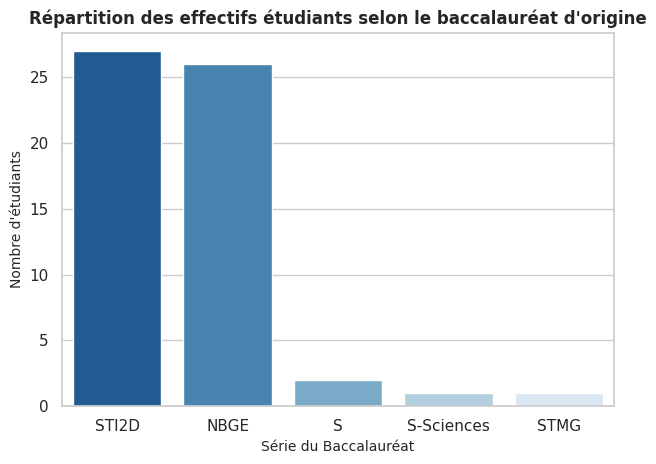

In [5]:
ordre_bac = df_res['bac'].value_counts().index
sns.countplot(data=df_res, x='bac', order=ordre_bac, palette='Blues_r')

plt.title("Répartition des effectifs étudiants selon le baccalauréat d'origine", fontsize=12, fontweight='bold')
plt.xlabel("Série du Baccalauréat", fontsize=10)
plt.ylabel("Nombre d'étudiants", fontsize=10)

plt.tight_layout()
plt.show()

**Analyse de la variable qualitative nominale (`bac`) :**
L'examen du diagramme en barres montre que la promotion est presque exclusivement polarisée autour de deux filières : `STI2D` (27 étudiants) et `NBGE (Nouveau Baccalauréat Général)` (26 étudiants). Les filières `S`, `S-Sciences` et `STMG` sont marginales et ne totalisent que 4 étudiants. Cette répartition implique une cohorte coupée en deux blocs distincts : d'un côté des profils technologiques avec des compétences pratiques affirmées, et de l'autre des profils issus de la réforme du baccalauréat général (NBGE) ayant des bagages théoriques diversifiés selon leurs spécialités. L'impact de cette dualité sera l'axe central de l'analyse des résultats.

## 3.2. Variable qualitative ordinale : Évaluation des avis de poursuite d'études (`avis_pe`)
**Objectif :** Cette analyse est menée afin d'étudier la distribution des décisions d'orientation rendues par le conseil de classe en fin de cursus, permettant de mesurer globalement le potentiel d'intégration des étudiants dans les cycles supérieurs.

/tmp/ipykernel_4581/3266749359.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_res, x='avis_pe', palette='Purples', edgecolor='black')


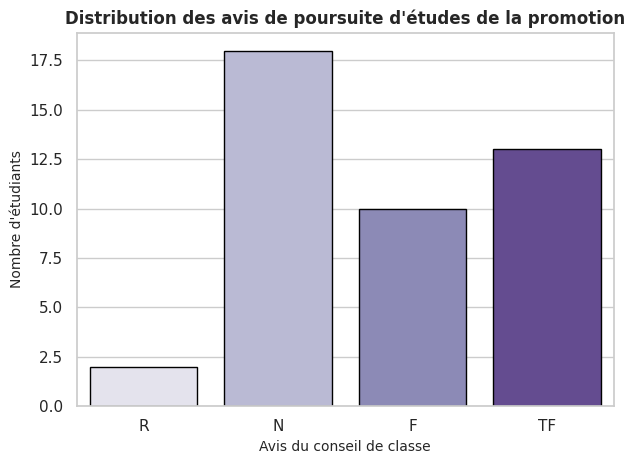

In [6]:
sns.countplot(data=df_res, x='avis_pe', palette='Purples', edgecolor='black')

plt.title("Distribution des avis de poursuite d'études de la promotion", fontsize=12, fontweight='bold')
plt.xlabel("Avis du conseil de classe", fontsize=10)
plt.ylabel("Nombre d'étudiants", fontsize=10)

plt.tight_layout()
plt.show()

**Analyse de la variable qualitative ordinale (`avis_pe`) :**
L'analyse du diagramme met en évidence que la modalité « Neutre » (N) est majoritaire avec 18 étudiants. Cependant, la dynamique globale de la promotion est positive : les avis favorables cumulés, à savoir « Très Favorable » (TF) avec 13 étudiants et « Favorable » (F) avec 10 étudiants, représentent la majorité des avis exprimés (23 étudiants). Les avis « Réservé » (R) restent marginaux (2 étudiants). On note également l'exclusion des 14 valeurs manquantes (NaN) qui correspondent aux abandons ou réorientations en cours de cursus, ce qui confirme la nécessité de se concentrer sur les données complètes du BUT 1 pour les analyses croisées.

## 3.3. Variable quantitative discrète : Analyse volumétrique des absences (`nb_absences`)
**Objectif :** Cette analyse est menée afin d'étudier la distribution du volume d'incidents d'absences par étudiant à partir des données consolidées, permettant de cartographier le niveau d'assiduité général de la promotion.

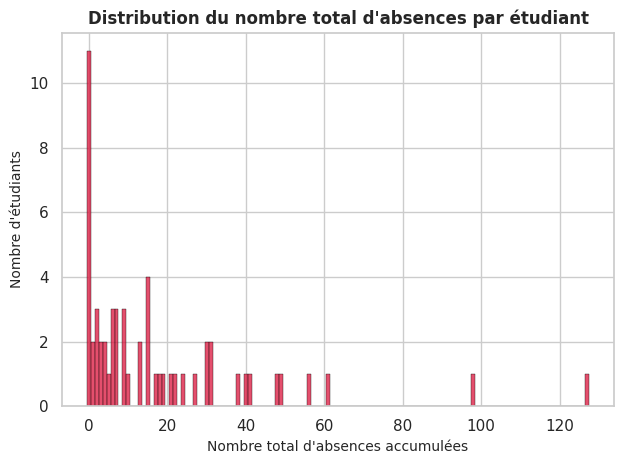

In [7]:
sns.histplot(data=df_res, x='nb_absences', color='crimson', discrete=True, edgecolor='black')

plt.title("Distribution du nombre total d'absences par étudiant", fontsize=12, fontweight='bold')
plt.xlabel("Nombre total d'absences accumulées", fontsize=10)
plt.ylabel("Nombre d'étudiants", fontsize=10)

plt.tight_layout()
plt.show()

**Analyse de la variable quantitative discrète (`nb_absences`) :**
La distribution est fortement asymétrique à droite (étalée vers les valeurs élevées). Un bloc majeur de la promotion fait preuve d'une assiduité stricte, avec un pic à 0 absence (plus de 20 étudiants). L'effectif chute de manière exponentielle pour les valeurs intermédiaires. On identifie cependant une traîne de profils d'étudiants accumulant un volume critique d'absences (au-delà de 10), ce qui caractérise un comportement de décrochage ou des difficultés personnelles qu'il faudra croiser avec les résultats.

## 3.4. Variable quantitative continue : Analyse des notes de l'UE 1.1 (`ue_1_1`)
**Objectif :** Cette analyse est menée afin d'étudier la distribution des moyennes obtenues dans la première Unité d'Enseignement du Semestre 1, permettant d'évaluer le niveau académique continu et la dispersion des performances.

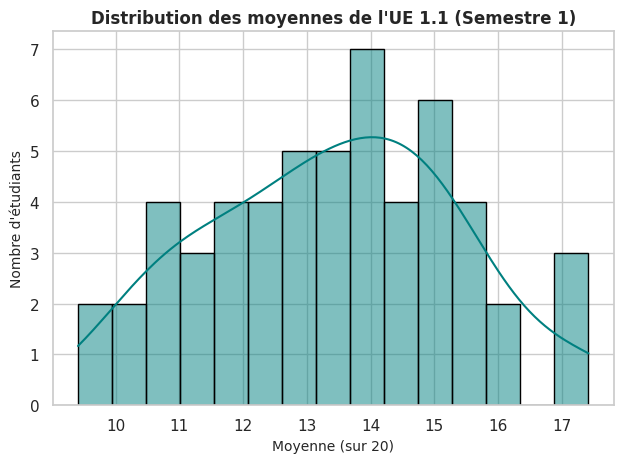

In [8]:
sns.histplot(data=df_res, x='ue_1_1', color='teal', kde=True, bins=15, edgecolor='black')

plt.title("Distribution des moyennes de l'UE 1.1 (Semestre 1)", fontsize=12, fontweight='bold')
plt.xlabel("Moyenne (sur 20)", fontsize=10)
plt.ylabel("Nombre d'étudiants", fontsize=10)

plt.tight_layout()
plt.show()

**Analyse de la variable quantitative continue (`ue_1_1`) :**
L'histogramme révèle une distribution asymétrique s'étirant vers la gauche. La concentration majeure des notes se situe dans l'intervalle [12 - 16], avec un pic modal prononcé autour de 14/20. Cette structure indique une maîtrise globale satisfaisante des compétences de cette unité d'enseignement par la majorité de la promotion. Les profils en échec (notes inférieures à 10/20) sont marginaux.

# 4. Étude Statistique Bivariée

## 4.1. Croisement de deux variables qualitatives : `bac` x `avis_pe`
**Objectif :** Déterminer la corrélation éventuelle entre le vivier de recrutement initial et la décision d'orientation post-BUT.

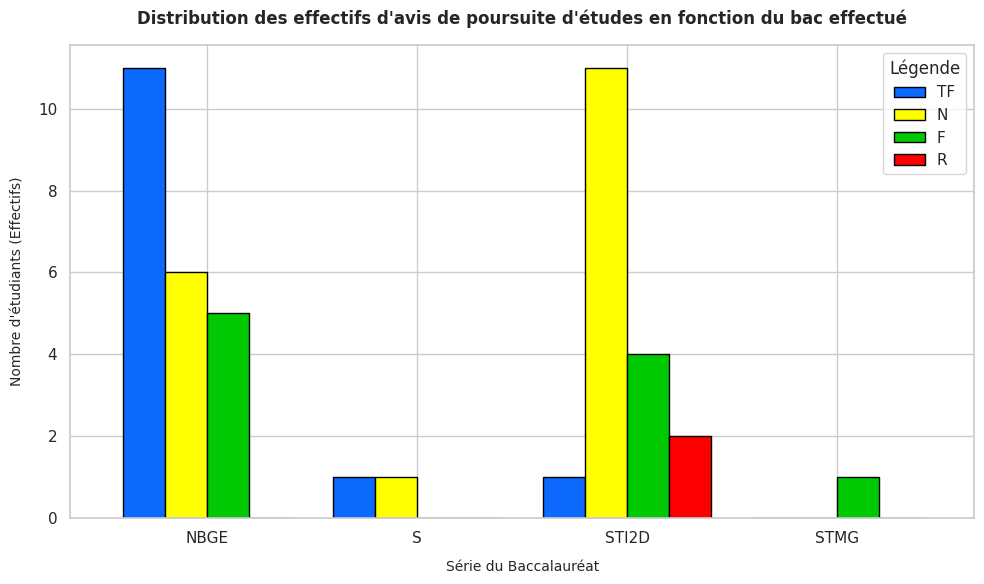

In [9]:
df_bac_avis = df_res[["bac", "avis_pe"]].dropna()
df_bac_avis = pd.crosstab(df_bac_avis["bac"], df_bac_avis["avis_pe"])
df_bac_avis = df_bac_avis.reindex(columns=["TF", "N", "F", "R"])

fig, ax = plt.subplots(figsize=(10, 6))
df_bac_avis.plot(
    kind="bar", color=["#0d6aff", "yellow", "#00c903", "red"], edgecolor="black", width=0.8, ax=ax
)

plt.title(
    "Distribution des effectifs d'avis de poursuite d'études en fonction du bac effectué",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Série du Baccalauréat", fontsize=10, labelpad=10)
plt.ylabel("Nombre d'étudiants (Effectifs)", fontsize=10, labelpad=10)
plt.xticks(rotation=0)
plt.legend(
    title="Légende",
    loc="upper right",
    frameon=True,
)

plt.tight_layout()
plt.show()

**Analyse du couple de variable 'bac' et 'avis_pe' :**
La distribution met en évidence une grande différences des avis de poursuite d'étude en fonction du bac effectué. À effectifs globaux équivalents, la filière générale montre en majorité une très forte envie de poursuivre leurs études apres le BUT. À l'inverse, la filière technologique présente un profil plus mitigé, à cause d'une majorité d'avis neutre. Les filières S et STMG ont un effectif trop faible pour en déduire des conclusions.

## 4.2. Croisement d'une variable quantitative et d'une variable qualitative : `bac` x `UE_1_1`
**Objectif :** Déterminer la corrélation éventuelle entre le bac choisi et les notes des étudiants.

/tmp/ipykernel_4581/3348582672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


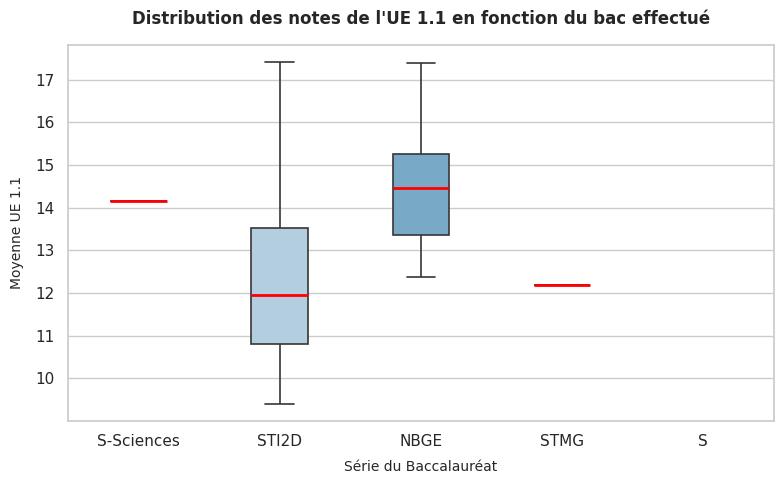

In [10]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_res,
    x="bac",
    y="ue_1_1",
    palette="Blues",
    width=0.4,
    linewidth=1.2,
    medianprops={
        "color": "red",
        "linewidth": 2
    },
)

plt.title(
    "Distribution des notes de l'UE 1.1 en fonction du bac effectué",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Série du Baccalauréat", fontsize=10, labelpad=8)
plt.ylabel("Moyenne UE 1.1", fontsize=10, labelpad=8)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Analyse du couple de variable 'bac' et 'UE_1_1' :**
La distribution met en évidence une différence marquée des performances académiques à l'UE 1.1 en fonction du bac effectué. À effectifs globaux équivalents, la filière générale montre une réussite plus homogène et plus élevée, avec une médiane se situant autour de 14,5. À l'inverse, la filière technologique présente un profil beaucoup plus mitigé et dispersé : malgré le fait que certains étudiants atteignent d'excellentes notes, la moitié de la classe se situe sous la barre des 12, avec des chutes sous la note de 10. Les filières S-Sciences, STMG et S ont un effectif d'une seule personne donc leur notes sont tout simplement la médiane.

## 4.3. Croisement d'un couple de variable quantitative : `nb_absences` x `UE_1_1`
**Objectif :** Déterminer la corrélation éventuelle entre le nombre d'absences et les notes des étudiants.

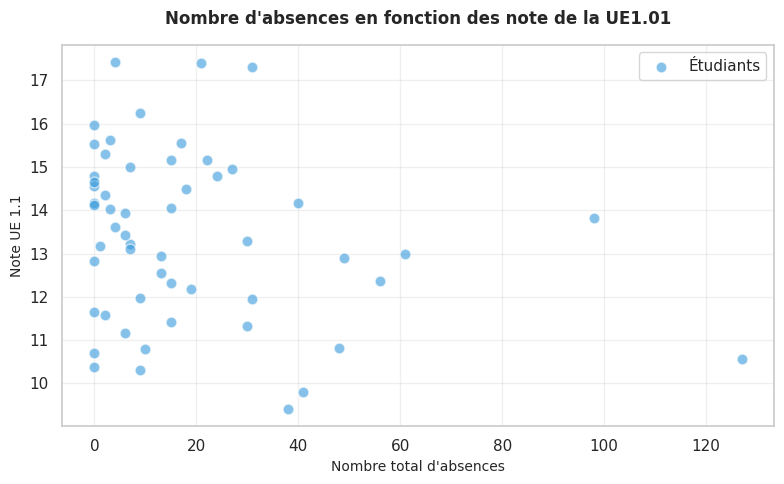

In [11]:
df_absxue = df_res[["nb_absences", "ue_1_1"]].dropna()

slope, intercept, r_value, p_value, std_err = stats.linregress(df_absxue["nb_absences"].values, df_absxue["ue_1_1"].values)
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df_absxue["nb_absences"].values,
    df_absxue["ue_1_1"].values,
    alpha=0.6,
    color="#3498db",
    edgecolors="white",
    s=60,
    label="Étudiants",
)

ax.set_title(
    "Nombre d'absences en fonction des note de la UE1.01",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Nombre total d'absences", fontsize=10)
ax.set_ylabel("Note UE 1.1", fontsize=10)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Analyse du couple de variables 'nb_absences' et 'UE_1_1' :**
Le graphique met en évidence une relation entre le nombre total d'absences et la note obtenue à l'UE 1.1. Le nuage de points montre que plus le volume d'absences augmente, plus les notes ont tendance à chuter.

## 4.4. Croisement d'un couple de variable quantitative : `UE_1_1` x `UE_1_2`
**Objectif :** Suivre la progression des étudiants entre le premier et le deuxième semestre

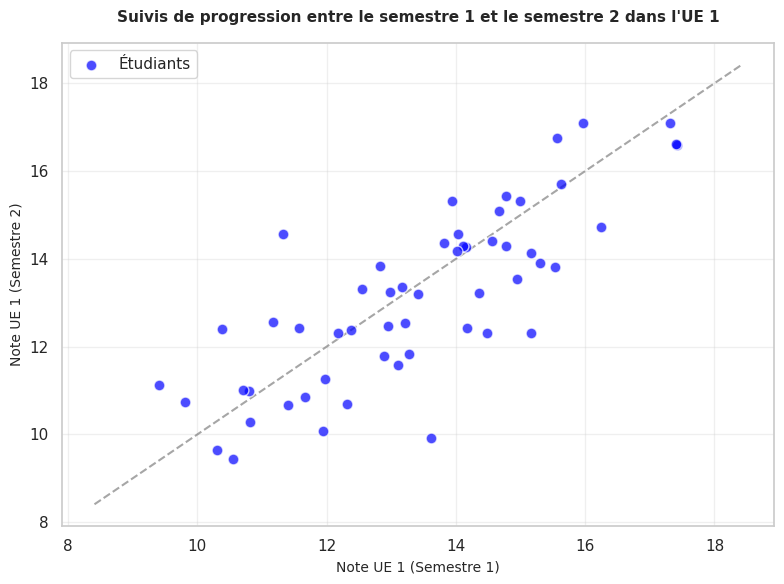

In [12]:
df_evo = df_res[["ue_1_1", "ue_1_2"]]
df_evo = df_evo.dropna()

x = df_evo["ue_1_1"].values
y = df_evo["ue_1_2"].values

fig, ax = plt.subplots(figsize=(8, 6))

limite_min = min(min(x), min(y)) - 1
limite_max = max(max(x), max(y)) + 1
ax.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    color="grey",
    linestyle="--",
    alpha=0.7,
)

ax.scatter(x, y, color="blue", alpha=0.7, s=60, edgecolors="white", zorder=3, label="Étudiants")

ax.set_title(
    "Suivis de progression entre le semestre 1 et le semestre 2 dans l'UE 1",
    fontsize=11,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Note UE 1 (Semestre 1)", fontsize=10)
ax.set_ylabel("Note UE 1 (Semestre 2)", fontsize=10)
ax.grid(alpha=0.3, zorder=0)

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

**Analyse du couple de variables 'UE_1_1' et 'UE_1_2' :**
Le graphique montre la progression des étudiants entre le premier et le second semestre dans l'UE 1. Tout les points au dessus de la droite f(x) = x représente une amélioration des résultats, tous les points en dessous de la droite représentent une baisse des résultats

## 4.5. Croisement d'une variable quantitative et d'une variable qualitative : `avis_pe` x `nb_absences`
**Objectif :** Déterminer une corrélation entre l'envie d'une poursuite d'étude et le nombre d'absences

/tmp/ipykernel_4581/4040530669.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ordre_groupes = df_pexabs.groupby("avis_pe")["nb_absences"].median().sort_values().index
/tmp/ipykernel_4581/4040530669.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(


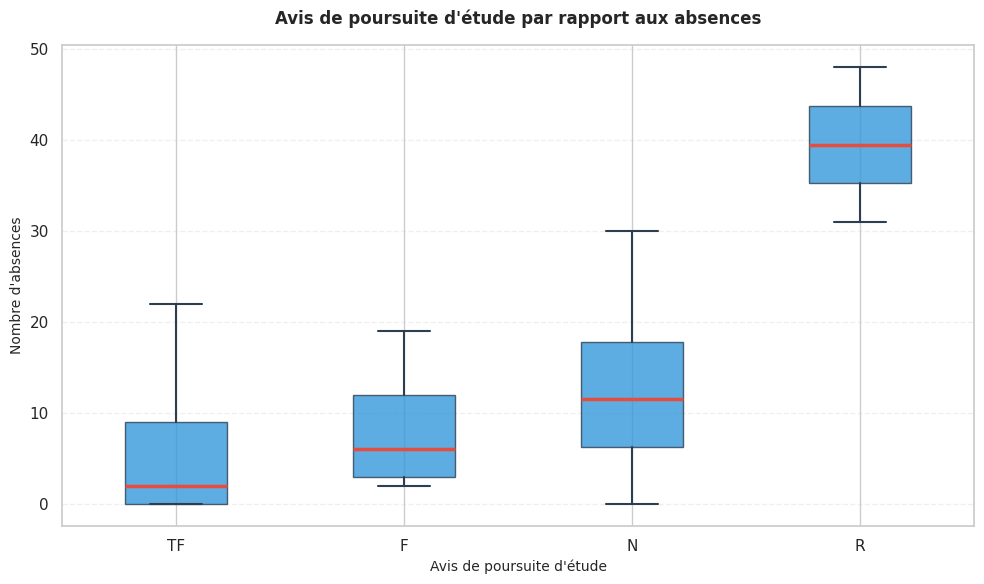

In [13]:
df_pexabs = df_res[["avis_pe", "nb_absences"]].dropna()

ordre_groupes = df_pexabs.groupby("avis_pe")["nb_absences"].median().sort_values().index

donnees_groupes = [df_pexabs[df_pexabs["avis_pe"] == g]["nb_absences"].values for g in ordre_groupes]

fig, ax = plt.subplots(figsize=(10, 6))

bplot = ax.boxplot(
    donnees_groupes,
    labels=ordre_groupes,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="#3498db", color="#2c3e50", alpha=0.8),
    medianprops=dict(color="#e74c3c", linewidth=2.5),
    whiskerprops=dict(color="#2c3e50", linewidth=1.5),
    capprops=dict(color="#2c3e50", linewidth=1.5)
)

ax.set_title(
    "Avis de poursuite d'étude par rapport aux absences",
    fontsize=12,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel("Avis de poursuite d'étude", fontsize=10)
ax.set_ylabel("Nombre d'absences", fontsize=10)
ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

**Analyse du couple de variables 'avis_pe' et 'nb_absences' :**
Le graphique met en évidence le fait qu'il y ait un lien entre l'envie d'une poursuite d'étude et l'assiduité en cours.on peut voir que les étudiants ayant un avis neutre ou réservé sont beaucoup moins assidus que les étudaints ayant un avis favorable ou très favorable.